#### OZON 

## Sales & Profitability Analysis — OZON Market
**Project objective**
The objective of this project is to analyze sales and profitability of an online store OZON Market and to identify practical opportunities to improve profit.

The analysis focuses not only on sales and revenue, but primarily on product profitability, pricing, assortment, marketplace costs, promotions and inventory management.

#### Key business questions

**The analysis aims to answer the following questions**:
- Which SKUs and product groups are the main profit drivers?
- Which products generate high revenue but have low or negative profitability?
- Where are there opportunities to increase profit within the existing assortment?
- Which products may have pricing opportunities?
- How did changes in price and discounts relate to sales volume and profit?
- Where is profit potentially lost because of marketplace costs, out-of-stock situations, excessive inventory or returns?
- Which actions should be prioritized over the next 90 days?

**Table of Contents**:

1. Data Loading and Preprocessing
2. Cleaning and verifying `unit_economics` dataframe
3. Data Mart: Sales by SKU and Month
4. Unit Economics Calculation
5. Unit Economics at Different Levels: SKU, Product_name and Month
6. SKU Segmentation: Sales vs. Profit Margin
7. Cost Leakage Analytics
8. Conclusions and Recommendations

**Data and methodology**

The analysis is based on monthly marketplace reports from OZON Market. The sales data was combined into analytical datasets at SKU-month level.

A separate COGS dataset was joined by SKU to calculate total product cost and final profit.

The analysis includes monthly and SKU-level profitability, profit margin, sales volume, product segmentation, sales variability, pricing analysis and inventory analysis.

For inventory analysis, the available stock reports were used.

In [1]:
import pandas as pd
from pathlib import Path  #Se folosește pentru a lucra cu numele fișierelor și căile către fișiere.
from glob import glob
import re  # Regular Expressions for variable 'match'
import os
import numpy as np
import matplotlib.pyplot as plt


## 1. Data Loading and Preprocessing


#### 1.1 Uploading file for COGS

In [2]:
file_path = os.path.expanduser(
    "~/Desktop/reports/OZON/cost_price.csv"
)

cost_price = pd.read_csv(
    file_path,
    sep=";"
)

In [3]:
cost_price.head()

,наименование,sku_маркета,sku_озона,аналитический_sku,категория,надкатегория,себестоимость
0,Набор наклеек для авто красный,авто_красный,авто_красный,авто_красный,наклейки,канцелярия и сувениры,80
1,Набор наклеек для авто желтый,авто_желтый,авто_желтый,авто_желтый,наклейки,канцелярия и сувениры,80
2,Набор наклеек для авто желтый с узорами,авто_желтый_узор,NaN,авто_желтый_узор,наклейки,канцелярия и сувениры,80
3,Стикерпак 3D,стикерпак_3D,стикерпак_3D,стикерпак_3D,стикерпак,канцелярия и сувениры,295
4,Стикерпак белый,стикерпак_белый,стикерпак_белый,стикерпак_белый,стикерпак,канцелярия и сувениры,55


In [4]:
cost_price = cost_price[
    ["sku_озона",
     "наименование",
     "категория",
     "себестоимость"
    ]
].copy()

In [5]:
cost_price.rename(columns=
                  { "sku_озона" : "sku",
                                "наименование" : "name",
                                "категория" : "category",
                                "себестоимость" : "cogs"
                                
    
},inplace = True)

In [6]:
cost_price.head()

,sku,name,category,cogs
0,авто_красный,Набор наклеек для авто красный,наклейки,80
1,авто_желтый,Набор наклеек для авто желтый,наклейки,80
2,NaN,Набор наклеек для авто желтый с узорами,наклейки,80
3,стикерпак_3D,Стикерпак 3D,стикерпак,295
4,стикерпак_белый,Стикерпак белый,стикерпак,55


#### 1.2 Uploading file `stocks`

In [7]:
stock_files = glob("/Users/sweetyolo/Desktop/reports/OZON/Управление остатками*.xlsx")


print(stock_files)

['/Users/sweetyolo/Desktop/reports/OZON/Управление остатками 08.07.2026 16-10.xlsx']


In [8]:
### Load current stock snapshot
stock_file = stock_files[0]

stock_cluster = pd.read_excel(
    stock_file,
    sheet_name="Товар-кластер",
    header=0
)

stock_cluster = stock_cluster.iloc[3:].reset_index(drop=True)

stock_cluster = stock_cluster.rename(columns={"Артикул": "sku"})


stock_warehouse = pd.read_excel(
    stock_file,
    sheet_name="Товар-склад",
    header=0
)

stock_warehouse = stock_warehouse.iloc[3:].reset_index(drop=True)

stock_warehouse = stock_warehouse.rename(columns={"Артикул": "sku"})


/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [9]:
stock_cluster.columns.tolist()


['sku',
 'Название товара',
 'Кластер',
 'Ликвидность',
 'Unnamed: 4',
 'Среднесуточные продажи за\xa028 дней\n\nШтук',
 'Дней без\xa0продаж',
 'Остатки на\xa0складах Ozon']

In [10]:
stock_by_city = stock_cluster.rename(columns={
 "Название товара":"product_name",
 "Кластер":"city",
 "Ликвидность":"liquidity",
 "Unnamed: 4": "days_left",
 "Среднесуточные продажи за\xa028 дней\n\nШтук":"average_daily_sales_for_28_days",
 "Дней без\xa0продаж":"days_no_sales",
 "Остатки на\xa0складах Ozon":"warehouse_stock"})


In [11]:
stock_by_city["days_no_sales"] = (
    stock_by_city["days_no_sales"]
    .astype(str)
    .str.replace("Больше ", "", regex=False)
)

In [12]:
stock_numeric_cols =[
    "days_left",  
    "days_no_sales",
    "average_daily_sales_for_28_days",
    "warehouse_stock"]

for col in stock_numeric_cols:
    stock_by_city[col] = pd.to_numeric(
        stock_by_city[col],
        errors="coerce"
    )

In [13]:
stock_by_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sku                              131 non-null    object 
 1   product_name                     131 non-null    object 
 2   city                             131 non-null    object 
 3   liquidity                        131 non-null    object 
 4   days_left                        73 non-null     float64
 5   average_daily_sales_for_28_days  129 non-null    float64
 6   days_no_sales                    131 non-null    int64  
 7   warehouse_stock                  131 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 8.3+ KB


In [14]:
stock_by_city.head()

,sku,product_name,city,liquidity,days_left,average_daily_sales_for_28_days,days_no_sales,warehouse_stock
0,сб_(4-)_белый,Силиконовый браслет донора сообщества DonorSea...,"Москва, МО и Дальние регионы","Без продаж, ограничен",NaN,0.0,120,2
1,ф_донор_L,"Футболка ""Донор крови, донор жизни!"", Размер L...",Самара,Без продаж,NaN,0.0,10,3
2,ф_донор_XL,"Футболка ""Донор крови, донор жизни!"", Размер X...",Самара,Без продаж,NaN,0.0,10,3
3,ф_донор_M,"Футболка ""Донор крови, донор жизни!"", Размер M...",Самара,Без продаж,NaN,0.0,10,2
4,сб_(4-)_красный,Силиконовый браслет AB(IV) Rh- (4-) донора соо...,Самара,Без продаж,NaN,0.0,120,3


#### 1.3 Uploading all files `Unit_economics`

In [15]:
unit_files = glob("/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика*.xlsx")

In [16]:
print(unit_files)

['/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.07.2026-07.07.2026.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.06.2026-30.06.2026.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.04.2026-30.04.2026 (1).xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.07.2025-31.07.2025.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.11.2025-30.11.2025.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.05.2026-31.05.2026 (1).xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.12.2025-31.12.2025.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.02.2026-28.02.2026.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.10.2025-31.10.2025.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.01.2026-31.01.2026.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.08.2025-31.08.2025.xlsx', '/Users/sweetyolo/Desktop/reports/OZON/Юнит-экономика_01.03.2026-31.03.2026.xl

In [17]:
unit_list = []

for file in unit_files:

    # Citim Excel-ul fără să folosim primul rând ca header
    df_raw = pd.read_excel(file, header=None)

    # Luăm textul din primul rând
    period_text = str(df_raw.iloc[0, 0])

    # Extragem perioada: 01.11.2025-30.11.2025
    match = re.search(
        r'(\d{2}\.\d{2}\.\d{4}-\d{2}\.\d{2}\.\d{4})',
        period_text
    )

    if match:
        period = match.group(1)

        # Extragem luna și anul din data de început
        start_date = pd.to_datetime(
            period.split("-")[0],
            format="%d.%m.%Y"
        )

        month = start_date.strftime("%Y-%m")

    else:
        period = None
        month = None

    # Citim tabelul propriu-zis, unde header-ul este pe rândul 4
    df = pd.read_excel(file, header=3)

    # Adăugăm coloanele
    df["period"] = period
    df["year_month"] = month


    unit_list.append(df)

unit_economics = pd.concat(unit_list, ignore_index=True)


/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/

In [18]:
print(unit_economics.shape)
unit_economics.head()

(460, 35)


,SKU,Артикул,Название товара,Схема работы,Себестоимость,Текущая цена,"Заказано товаров, шт","Доставлено товаров, шт","Возвращено товаров, шт",Выручка,...,Звёздные товары,Платный бренд,Отзывы,Доля от продаж,Прибыль за шт,Индекс цен,Доступность товаров,Прибыль за период,period,year_month
0,1867686995,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" жесткая",FBO,0,639,3,2,0,1151.01,...,-19.18,0.0,0.0,0.8607,550.03,NaN,Срочно поставить,1100.06,01.07.2026-07.07.2026,2026-07
1,1897406873,авто_красный,Наклейка на автомобиль донора крови DonorSearch,FBO,0,408,1,1,0,388.57,...,-6.12,0.0,0.0,0.7849,320.24,NaN,Срочно поставить,320.24,01.07.2026-07.07.2026,2026-07
2,1855673128,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,FBO,0,295,2,1,0,333.18,...,-5.85,0.0,0.0,0.8120,316.69,NaN,Срочно поставить,316.69,01.07.2026-07.07.2026,2026-07
3,3782116317,Вымпел,"Вымпел для доноров DonorSearch, двусторонний, ...",FBO,0,859,1,0,0,0.00,...,0.00,0.0,0.0,NaN,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07
4,3735279254,магнит,"Магнит для доноров крови ""Почетный донор"" от D...",FBO,0,291,0,0,0,0.00,...,0.00,0.0,0.0,NaN,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07


## 2. Cleaning and verifying `unit_economics` dataframe

In [19]:
unit_economics["year_month"].unique()

array(['2026-07', '2026-06', '2026-04', '2025-07', '2025-11', '2026-05',
       '2025-12', '2026-02', '2025-10', '2026-01', '2025-08', '2026-03',
       '2025-09'], dtype=object)

In [20]:
unit_economics["period"].unique()

array(['01.07.2026-07.07.2026', '01.06.2026-30.06.2026',
       '01.04.2026-30.04.2026', '01.07.2025-31.07.2025',
       '01.11.2025-30.11.2025', '01.05.2026-31.05.2026',
       '01.12.2025-31.12.2025', '01.02.2026-28.02.2026',
       '01.10.2025-31.10.2025', '01.01.2026-31.01.2026',
       '01.08.2025-31.08.2025', '01.03.2026-31.03.2026',
       '01.09.2025-30.09.2025'], dtype=object)

In [21]:
unit_economics.groupby(["period","SKU"]).size().value_counts().head()

1    460
Name: count, dtype: int64

In [22]:
unit_economics.duplicated().sum()

0

In [23]:
unit_economics.columns.tolist()

['SKU',
 'Артикул',
 'Название товара',
 'Схема работы',
 'Себестоимость',
 'Текущая цена',
 'Заказано товаров, шт',
 'Доставлено товаров, шт',
 'Возвращено товаров, шт',
 'Выручка',
 'Баллы за скидки',
 'Программы партнёров',
 'Вознаграждение Ozon',
 'Эквайринг',
 'Обработка отправления',
 'Логистика',
 'Доставка до места выдачи',
 'Стоимость размещения',
 'Обработка возврата',
 'Обратная логистика',
 'Утилизация',
 'Дополнительная \nобработка ОВХ',
 'Операционные ошибки',
 'Оплата за клик',
 'Оплата за заказ',
 'Звёздные товары',
 'Платный бренд',
 'Отзывы',
 'Доля от продаж',
 'Прибыль за шт',
 'Индекс цен',
 'Доступность товаров',
 'Прибыль за период',
 'period',
 'year_month']

In [24]:
cost_columns = [
    "Утилизация",
    "Обработка отправления",
    "Логистика",
    "Доставка до места выдачи",
    "Стоимость размещения",
    "Обработка возврата",
    "Обратная логистика",
    "Эквайринг",
    "Дополнительная \nобработка ОВХ",
    "Операционные ошибки",
    "Оплата за клик",
    "Оплата за заказ",
    "Платный бренд",
    "Отзывы",
    "Индекс цен"

]

for col in cost_columns:
    print(
        col,
        "→ 0:", (unit_economics[col] == 0).sum(),
        "→ total:", len(unit_economics),
        "→ non-zero:", (unit_economics[col] != 0).sum()
    )

Утилизация → 0: 460 → total: 460 → non-zero: 0
Обработка отправления → 0: 460 → total: 460 → non-zero: 0
Логистика → 0: 141 → total: 460 → non-zero: 319
Доставка до места выдачи → 0: 146 → total: 460 → non-zero: 314
Стоимость размещения → 0: 301 → total: 460 → non-zero: 159
Обработка возврата → 0: 434 → total: 460 → non-zero: 26
Обратная логистика → 0: 416 → total: 460 → non-zero: 44
Эквайринг → 0: 460 → total: 460 → non-zero: 0
Дополнительная 
обработка ОВХ → 0: 460 → total: 460 → non-zero: 0
Операционные ошибки → 0: 460 → total: 460 → non-zero: 0
Оплата за клик → 0: 460 → total: 460 → non-zero: 0
Оплата за заказ → 0: 460 → total: 460 → non-zero: 0
Платный бренд → 0: 426 → total: 460 → non-zero: 34
Отзывы → 0: 446 → total: 460 → non-zero: 14
Индекс цен → 0: 0 → total: 460 → non-zero: 460


In [25]:
print(f"Отзывы column",unit_economics["Отзывы"].unique())
print("")
print(f"Платный бренд",unit_economics["Платный бренд"].unique())
# The "Отзывы" and "Платный бренд" columns are not relevant to the unit economics analysis, so it is excluded.

Отзывы column [  0.   -35.41 -10.42 -15.12  -2.8  -10.7  -14.55  -2.54  -6.51  -2.62]

Платный бренд [  0.   -51.94 -27.8  -21.2  -18.   -16.36 -13.75  -8.9   -7.5   -6.94
  -7.    -6.95  -5.25  -3.5   -4.5   -2.75  -2.65  -2.5   -1.75  -5.45
 -22.25  -8.25  -2.25  -3.95  -3.75  -4.09]


## 3. Build the  `sales_fact` dataframe

Create a wide **sales_fact** table, where each row represents a unique **SKU** for a given **month**. The table includes product quantities at each stage of the order lifecycle (shipped, delivered, undelivered, returned), as well as revenue metrics.

In [26]:
sales_fact = unit_economics[
    [
        "Артикул",
        "Название товара",
        "Текущая цена",
        "Заказано товаров, шт",
        "Доставлено товаров, шт",
        "Возвращено товаров, шт",
        "Выручка",
        "Баллы за скидки",
        "Программы партнёров",
        "Вознаграждение Ozon",
        "Логистика",
        "Доставка до места выдачи",
        "Стоимость размещения",
        "Обработка возврата",
        "Обратная логистика",
        "Звёздные товары",
        "Доля от продаж",
        "Прибыль за шт",
        "Доступность товаров",
        "Прибыль за период",
        "period",
        "year_month"
    ]
].copy()

In [27]:
sales_fact = sales_fact.rename(columns={
    "Артикул": "sku",
    "Название товара": "product_name",
    
    "Текущая цена": "current_price",
    "Заказано товаров, шт": "ordered_qty",
    "Доставлено товаров, шт": "delivered_qty",
    "Возвращено товаров, шт": "returned_qty",
    "Выручка": "revenue",
    "Баллы за скидки": "discount_points",
    "Программы партнёров": "partner_programs",
    
    "Вознаграждение Ozon": "ozon_commission",
    "Логистика": "logistics",
    "Доставка до места выдачи": "delivery_to_pickup_point",
    "Стоимость размещения": "storage",
    "Обработка возврата": "return_processing",
    "Обратная логистика": "reverse_logistics",
    
    "Звёздные товары": "star_products",
    "Платный бренд": "paid_brand",
    
    "Доля от продаж": "sales_share",
    "Прибыль за шт": "profit_per_unit_ozon",
    "Доступность товаров": "availability",
    "Прибыль за период": "profit_period_ozon",
    
    "period": "period",
    "year_month": "year_month"
})

In [28]:
sales_fact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sku                       460 non-null    object 
 1   product_name              460 non-null    object 
 2   current_price             460 non-null    int64  
 3   ordered_qty               460 non-null    int64  
 4   delivered_qty             460 non-null    int64  
 5   returned_qty              460 non-null    int64  
 6   revenue                   460 non-null    float64
 7   discount_points           460 non-null    float64
 8   partner_programs          460 non-null    float64
 9   ozon_commission           460 non-null    float64
 10  logistics                 460 non-null    float64
 11  delivery_to_pickup_point  460 non-null    float64
 12  storage                   460 non-null    float64
 13  return_processing         460 non-null    int64  
 14  reverse_lo

In [29]:
sales_fact["year_month"] = pd.to_datetime(
    sales_fact["year_month"],
    format="%Y-%m"
).dt.to_period("M")

In [30]:
sales_fact = sales_fact.merge(cost_price[["sku","cogs"]],
                             on="sku", how="left")

In [31]:
sales_fact.head()

,sku,product_name,current_price,ordered_qty,delivered_qty,returned_qty,revenue,discount_points,partner_programs,ozon_commission,...,return_processing,reverse_logistics,star_products,sales_share,profit_per_unit_ozon,availability,profit_period_ozon,period,year_month,cogs
0,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" жесткая",639,3,2,0,1151.01,126.99,0.0,-12.78,...,0,0.0,-19.18,0.8607,550.03,Срочно поставить,1100.06,01.07.2026-07.07.2026,2026-07,190
1,авто_красный,Наклейка на автомобиль донора крови DonorSearch,408,1,1,0,388.57,19.43,0.0,-4.08,...,0,0.0,-6.12,0.7849,320.24,Срочно поставить,320.24,01.07.2026-07.07.2026,2026-07,80
2,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,295,2,1,0,333.18,56.82,0.0,-3.90,...,0,0.0,-5.85,0.8120,316.69,Срочно поставить,316.69,01.07.2026-07.07.2026,2026-07,37
3,Вымпел,"Вымпел для доноров DonorSearch, двусторонний, ...",859,1,0,0,0.00,0.00,0.0,0.00,...,0,0.0,0.00,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07,400
4,магнит,"Магнит для доноров крови ""Почетный донор"" от D...",291,0,0,0,0.00,0.00,0.0,0.00,...,0,0.0,0.00,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07,50


In [32]:
sales_fact["cogs"].isna().sum()

0

In [33]:
sales_fact.columns.tolist()

['sku',
 'product_name',
 'current_price',
 'ordered_qty',
 'delivered_qty',
 'returned_qty',
 'revenue',
 'discount_points',
 'partner_programs',
 'ozon_commission',
 'logistics',
 'delivery_to_pickup_point',
 'storage',
 'return_processing',
 'reverse_logistics',
 'star_products',
 'sales_share',
 'profit_per_unit_ozon',
 'availability',
 'profit_period_ozon',
 'period',
 'year_month',
 'cogs']

In [34]:
sales_fact.shape

(460, 23)

In [35]:
sales_fact["cogs_total"] = sales_fact["cogs"] * sales_fact["delivered_qty"]

In [36]:
sales_fact.head()

,sku,product_name,current_price,ordered_qty,delivered_qty,returned_qty,revenue,discount_points,partner_programs,ozon_commission,...,reverse_logistics,star_products,sales_share,profit_per_unit_ozon,availability,profit_period_ozon,period,year_month,cogs,cogs_total
0,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" жесткая",639,3,2,0,1151.01,126.99,0.0,-12.78,...,0.0,-19.18,0.8607,550.03,Срочно поставить,1100.06,01.07.2026-07.07.2026,2026-07,190,380
1,авто_красный,Наклейка на автомобиль донора крови DonorSearch,408,1,1,0,388.57,19.43,0.0,-4.08,...,0.0,-6.12,0.7849,320.24,Срочно поставить,320.24,01.07.2026-07.07.2026,2026-07,80,80
2,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,295,2,1,0,333.18,56.82,0.0,-3.90,...,0.0,-5.85,0.8120,316.69,Срочно поставить,316.69,01.07.2026-07.07.2026,2026-07,37,37
3,Вымпел,"Вымпел для доноров DonorSearch, двусторонний, ...",859,1,0,0,0.00,0.00,0.0,0.00,...,0.0,0.00,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07,400,0
4,магнит,"Магнит для доноров крови ""Почетный донор"" от D...",291,0,0,0,0.00,0.00,0.0,0.00,...,0.0,0.00,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07,50,0


In [37]:
sales_fact["avg_price_per_unit"] = (sales_fact["revenue"] / sales_fact["delivered_qty"]).round(2).fillna(0)

In [38]:
sales_fact["delivered_rate"] = (sales_fact["delivered_qty"] / sales_fact["ordered_qty"].replace(0,np.nan)*100).round(2)

In [39]:
sales_fact.head()

,sku,product_name,current_price,ordered_qty,delivered_qty,returned_qty,revenue,discount_points,partner_programs,ozon_commission,...,sales_share,profit_per_unit_ozon,availability,profit_period_ozon,period,year_month,cogs,cogs_total,avg_price_per_unit,delivered_rate
0,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" жесткая",639,3,2,0,1151.01,126.99,0.0,-12.78,...,0.8607,550.03,Срочно поставить,1100.06,01.07.2026-07.07.2026,2026-07,190,380,575.50,66.67
1,авто_красный,Наклейка на автомобиль донора крови DonorSearch,408,1,1,0,388.57,19.43,0.0,-4.08,...,0.7849,320.24,Срочно поставить,320.24,01.07.2026-07.07.2026,2026-07,80,80,388.57,100.00
2,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,295,2,1,0,333.18,56.82,0.0,-3.90,...,0.8120,316.69,Срочно поставить,316.69,01.07.2026-07.07.2026,2026-07,37,37,333.18,50.00
3,Вымпел,"Вымпел для доноров DonorSearch, двусторонний, ...",859,1,0,0,0.00,0.00,0.0,0.00,...,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07,400,0,0.00,0.00
4,магнит,"Магнит для доноров крови ""Почетный донор"" от D...",291,0,0,0,0.00,0.00,0.0,0.00,...,NaN,NaN,Срочно поставить,0.00,01.07.2026-07.07.2026,2026-07,50,0,0.00,NaN


## 4. Unit Economics Calculation
* Revenue – Revenue generated from delivered products, including discounts.
* COGS (Cost of Goods Sold) – Total COGS aggregated from the cost_price table.
* Marketplace_fee - Total fees charged by the Yandex marketplace, aggregated from the United_orders report.
* Gross Profit = Revenue − COGS − Marketplace Fee  or  Profit_period_ozon(after discount) - COGS

In [40]:
sales_fact["gross_profit"] = (
    sales_fact["profit_period_ozon"]
    - sales_fact["cogs_total"]

)
sales_fact["profit_margin_pct"] = (
    sales_fact["gross_profit"]
    / sales_fact["revenue"].replace(0, np.nan)
    * 100
).round(2)


print("Unit Economics calculated successfully!:")
sales_fact[[
    "sku", "year_month", "revenue", "cogs_total","gross_profit","profit_margin_pct",
]].head(10)

Unit Economics calculated successfully!:


,sku,year_month,revenue,cogs_total,gross_profit,profit_margin_pct
0,жмяка_сердце_жест,2026-07,1151.01,380,720.06,62.56
1,авто_красный,2026-07,388.57,80,240.24,61.83
2,сб_(1+)_красный,2026-07,333.18,37,279.69,83.95
3,Вымпел,2026-07,0.00,0,0.00,NaN
4,магнит,2026-07,0.00,0,0.00,NaN
5,стикерпак_3д_2стикера,2026-07,0.00,0,0.00,NaN
6,ремувка_вышивка,2026-07,0.00,0,0.00,NaN
7,Брелок_металлический_розовый,2026-07,0.00,0,0.00,NaN
8,Брелок_металлический_голубой,2026-07,0.00,0,0.00,NaN
9,Брелок_металлический_красный,2026-07,0.00,0,0.00,NaN


In [41]:
print("Overall Totals Across All SKUs and Months:")
totals = sales_fact[["revenue", "cogs_total","gross_profit"]].sum()
totals.round(0)

Overall Totals Across All SKUs and Months:


revenue         542263.0
cogs_total      252666.0
gross_profit    217276.0
dtype: float64

In [42]:
sales_fact["revenue"].eq(0).sum()


146

In [43]:
sales_fact["revenue"].isna().sum()


0

In [44]:
sales_fact["profit_margin_pct"].isna().sum()

146

In [45]:
sales_fact["gross_profit"].isna().sum()

0

## 5. Unit Economics Analysis
##### Profitability is analyzed at multiple aggregation levels:
* SKU level – to evaluate the profitability of individual products.
* Product_level – to compare the performance of product categories.
* Monthly level – to analyze profitability trends over time.
Cluster (city) level: Revenue and profit cannot be calculated by cluster because the order reports do not contain cluster or city information.

In [46]:
#4.1 Analyzis by SKU for all period
# each row = SKU for all period
sku_analysis = (
    sales_fact
    .groupby(["sku", "product_name"], as_index=False)
    .agg(
        ordered_qty=("ordered_qty", "sum"),
        delivered_qty=("delivered_qty", "sum"),
        returned_qty=("returned_qty", "sum"),
        revenue=("revenue", "sum"),
        cogs_total=("cogs_total", "sum"),
        profit_period_ozon=("profit_period_ozon", "sum"),
        gross_profit=("gross_profit", "sum")
    )
)

sku_analysis["profit_per_unit"] = (
    sku_analysis["gross_profit"]
    / sku_analysis["delivered_qty"].replace(0, np.nan)
).round(2)

sku_analysis["profit_margin_pct"] = (
    sku_analysis["gross_profit"]
    / sku_analysis["revenue"].replace(0, np.nan)
    * 100
).round(2)

In [47]:
display(sku_analysis.sort_values("profit_margin_pct", ascending = False).head())
display(sku_analysis.info())

,sku,product_name,ordered_qty,delivered_qty,returned_qty,revenue,cogs_total,profit_period_ozon,gross_profit,profit_per_unit,profit_margin_pct
39,сб_(3+)_красный,Силиконовый браслет B(III) Rh+ (3+) донора соо...,34,31,0,8977.95,1147,8456.08,7309.08,235.78,81.41
37,сб_(2-)_красный,Силиконовый браслет A(II) Rh- (2-) донора сооб...,17,16,0,4406.83,592,4178.08,3586.08,224.13,81.38
34,сб_(2+)_белый,Силиконовый браслет донора сообщества DonorSea...,11,10,0,3033.87,550,2921.67,2371.67,237.17,78.17
31,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,52,49,0,14132.37,1813,12663.52,10850.52,221.44,76.78
33,сб_(1-)_красный,Силиконовый браслет 0(I) Rh- (1-) донора сообщ...,23,22,0,6562.88,814,5848.42,5034.42,228.84,76.71


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sku                 64 non-null     object 
 1   product_name        64 non-null     object 
 2   ordered_qty         64 non-null     int64  
 3   delivered_qty       64 non-null     int64  
 4   returned_qty        64 non-null     int64  
 5   revenue             64 non-null     float64
 6   cogs_total          64 non-null     int64  
 7   profit_period_ozon  64 non-null     float64
 8   gross_profit        64 non-null     float64
 9   profit_per_unit     62 non-null     float64
 10  profit_margin_pct   62 non-null     float64
dtypes: float64(5), int64(4), object(2)
memory usage: 5.6+ KB


None

In [48]:
print(sku_analysis["profit_margin_pct"].nunique())
print(sku_analysis["profit_margin_pct"].unique())

62
[  41.94   57.24   67.46   63.91   37.32   56.94   16.05   50.08   63.41
   62.16   74.13   57.73   41.67   22.82   33.16   26.77   12.67   62.54
   59.99   56.48   45.52   41.03   51.39   50.06   45.79   36.89 -112.89
   48.68   23.27   41.23   71.2    76.78   70.42   76.71   78.17   73.56
   71.47   81.38   71.15   81.41   60.19   74.9    67.9    73.62     nan
   51.3    27.93   54.08   -0.62  -25.25 -242.1    40.11 -296.43    3.29
   17.56   46.16   30.71   51.51  -63.88  -37.07   21.09   55.27 -260.04]


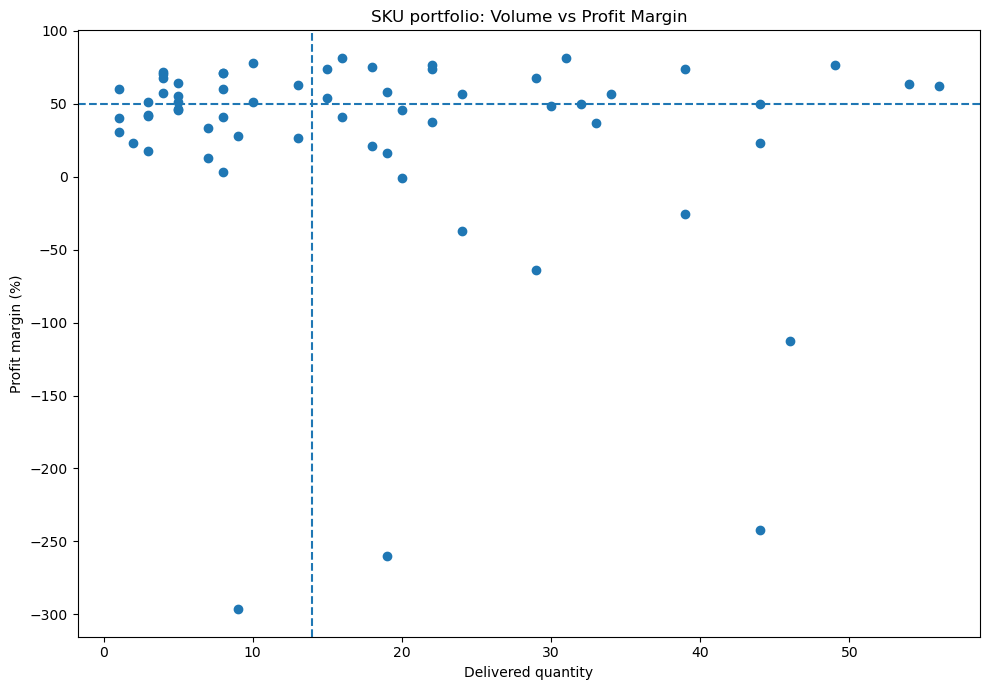

In [49]:
plt.figure(figsize=(10, 7))

plt.scatter(
    sku_analysis["delivered_qty"],
    sku_analysis["profit_margin_pct"]
)

plt.xlabel("Delivered quantity")
plt.ylabel("Profit margin (%)")
plt.title("SKU portfolio: Volume vs Profit Margin")

plt.axvline(
    sku_analysis["delivered_qty"].median(),
    linestyle="--"
)

plt.axhline(
    sku_analysis["profit_margin_pct"].median(),
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [50]:
#4.2 By SKU
by_sku = sales_fact.groupby(["sku", "product_name"]).agg(
    revenue=("revenue", "sum"),
    qty_delivered=("delivered_qty", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index().sort_values("gross_profit", ascending=False)

print("Top-10 SKU by profit:")
by_sku.head(10)

Top-10 SKU by profit:


,sku,product_name,revenue,qty_delivered,gross_profit
9,жмяка_сердце_мягкий,"Кистевой эспандер DonorSearch ""Жмяка"" сердце м...",38480.04,56,23918.42
8,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" жесткая",35918.15,54,22775.18
10,значок_50,"Значок DonorSearch ""50 донаций"", металл, 26x19...",26247.33,22,19458.36
23,обложка_красная,Обложка для паспорта DonorSearch экокожа красн...,25018.93,44,12523.59
2,Брелок_металлический_красный,Брелок для ключей автомобиля DonorSearch метал...,18451.79,29,12448.46
7,жмяка_банан,"Кистевой эспандер DonorSearch ""Жмяка"" банан",24196.08,32,12117.97
18,набор_значков_друзья,Набор металлических значков DonorSearch для др...,20185.41,8,12109.41
11,значок_друзья,Металлический значок DonorSearch для друзей со...,20425.56,19,11791.67
31,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,14132.37,49,10850.52
35,сб_(2+)_красный,Силиконовый браслет A(II) Rh+ (2+) донора сооб...,11536.51,39,8485.68


In [51]:
print(by_sku.info())

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 9 to 58
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sku            64 non-null     object 
 1   product_name   64 non-null     object 
 2   revenue        64 non-null     float64
 3   qty_delivered  64 non-null     int64  
 4   gross_profit   64 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 3.0+ KB
None


In [52]:
# 4.3. At the monthly level – to analyze profitability trends over time.
by_month = sales_fact.groupby("year_month").agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    delivered_qty=("delivered_qty","sum")
).reset_index().sort_values("year_month")

by_month["profit_margin_pct"] = (
    by_month["gross_profit"]
    / by_month["revenue"].replace(0, np.nan)
    * 100
).round(2)

by_month

,year_month,revenue,gross_profit,delivered_qty,profit_margin_pct
0,2025-07,41897.06,16972.76,67,40.51
1,2025-08,44893.44,16720.15,70,37.24
2,2025-09,109611.85,32071.43,216,29.26
3,2025-10,56646.34,-7874.90,249,-13.90
4,2025-11,48418.22,20977.30,105,43.33
5,2025-12,5604.70,3335.93,15,59.52
6,2026-01,31059.72,19679.20,44,63.36
7,2026-02,28738.30,18613.03,45,64.77
8,2026-03,22842.05,15371.23,44,67.29
9,2026-04,60961.62,34621.55,95,56.79


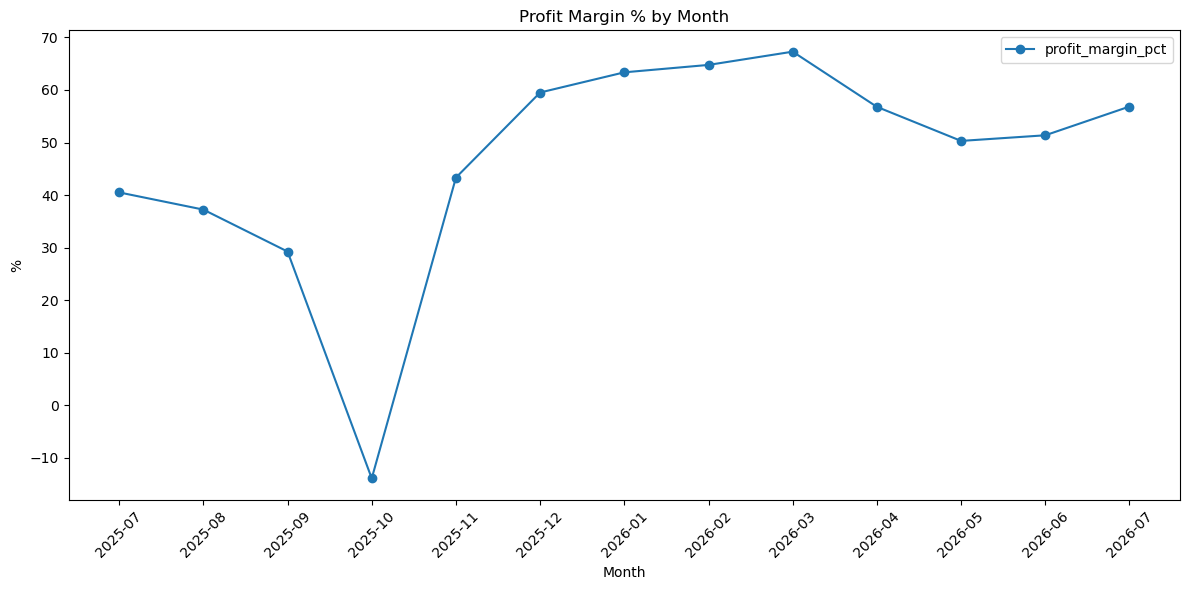

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    by_month["year_month"].astype(str),
    by_month["profit_margin_pct"],
    marker="o",
    label="profit_margin_pct"
)



plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("%")
plt.title("Profit Margin % by Month")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# 4.4.Cluster-Level Analysis
# At the cluster level, we analyze warehouse stock, average daily sales,
# and days without sales, as revenue data is not available at the cluster level.

by_cluster_stock = stock_by_city.groupby("city").agg(
    warehouse_stock=("warehouse_stock", "sum"),
    average_daily_sales_for_28_days=("average_daily_sales_for_28_days", "sum"),
    days_no_sales=("days_no_sales","sum")
).reset_index()

by_cluster_stock

,city,warehouse_stock,average_daily_sales_for_28_days,days_no_sales
0,Воронеж,0,0.04,0
1,Дальний Восток,0,0.23,0
2,Екатеринбург,0,0.14,0
3,Казань,43,0.16,781
4,Калининград,0,0.04,0
5,Краснодар,0,0.08,0
6,Красноярск,0,0.42,0
7,Махачкала,0,0.08,0
8,"Москва, МО и Дальние регионы",14,1.65,485
9,Новосибирск,0,0.37,0


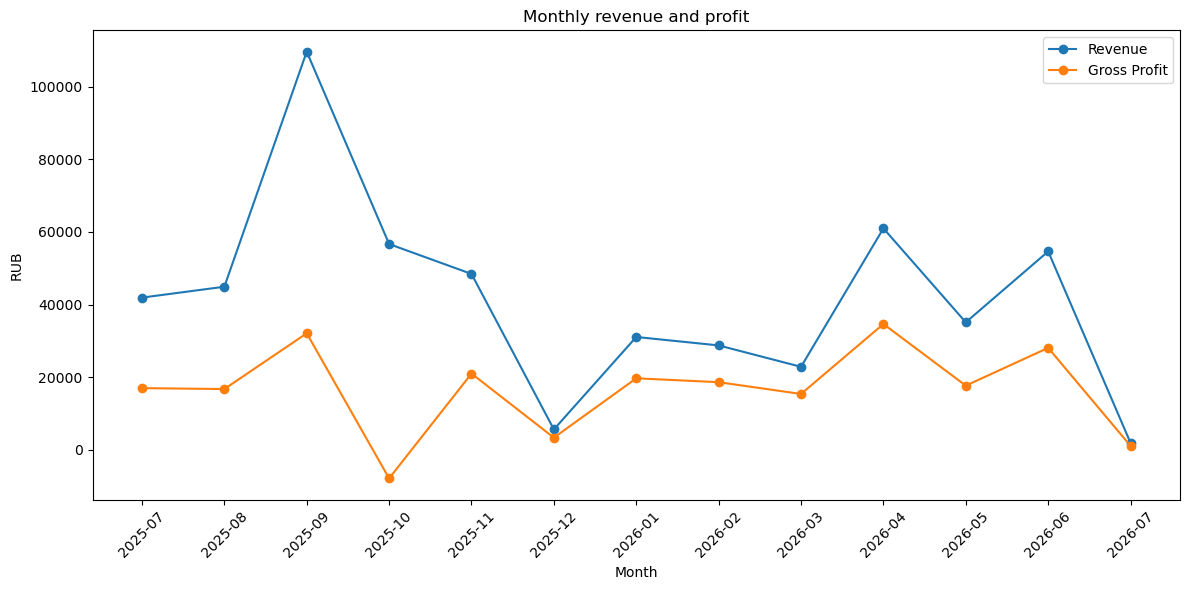

In [55]:
plt.figure(figsize=(12, 6))

plt.plot(
    by_month["year_month"].astype(str),
    by_month["revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    by_month["year_month"].astype(str),
    by_month["gross_profit"],
    marker="o",
    label="Gross Profit"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("RUB")
plt.title("Monthly revenue and profit")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
price_analysis = sales_fact[[
        "sku",
        "year_month",
        "current_price",
        "avg_price_per_unit",
        "delivered_qty",
        "revenue",
        "gross_profit"]].copy()

In [57]:
# this is for analyzing specific sku, in case would be needed
price_analysis[
    price_analysis["sku"] == "сб_(1+)_красный"
].sort_values("year_month")

,sku,year_month,current_price,avg_price_per_unit,delivered_qty,revenue,gross_profit
140,сб_(1+)_красный,2025-07,295,276.08,3,828.24,780.02
356,сб_(1+)_красный,2025-08,295,333.18,4,1332.70,1040.58
433,сб_(1+)_красный,2025-09,295,254.60,12,3055.15,2265.05
292,сб_(1+)_красный,2025-10,295,261.33,6,1568.00,1170.77
183,сб_(1+)_красный,2025-11,295,270.50,4,1082.00,771.78
326,сб_(1+)_красный,2026-01,295,326.21,3,978.63,776.30
257,сб_(1+)_красный,2026-02,295,332.80,4,1331.18,1021.34
394,сб_(1+)_красный,2026-03,295,294.75,4,1179.00,883.33
109,сб_(1+)_красный,2026-04,295,305.97,3,917.92,682.95
216,сб_(1+)_красный,2026-05,295,322.56,2,645.13,498.70


In [58]:
price_analysis["price_change_pct"] = (
    price_analysis
    .groupby("sku")["avg_price_per_unit"]
    .pct_change() * 100
).round(2)

price_analysis["qty_change_pct"] = (
    price_analysis
    .groupby("sku")["delivered_qty"]
    .pct_change() * 100
).round(2)

price_analysis.sort_values(["sku", "year_month"])[["sku","year_month","current_price","avg_price_per_unit","delivered_qty","revenue","gross_profit","price_change_pct","qty_change_pct"]].head(30)

,sku,year_month,current_price,avg_price_per_unit,delivered_qty,revenue,gross_profit,price_change_pct,qty_change_pct
317,Бафф_красный,2026-01,1100,1013.01,3,3039.03,1274.51,NaN,NaN
334,Брелок_металлический_голубой,2026-01,629,0.00,0,0.00,0.00,NaN,NaN
270,Брелок_металлический_голубой,2026-02,629,0.00,0,0.00,0.00,NaN,NaN
392,Брелок_металлический_голубой,2026-03,629,680.42,2,1360.85,914.91,inf,inf
112,Брелок_металлический_голубой,2026-04,629,610.93,1,610.93,385.36,16.21,0.00
238,Брелок_металлический_голубой,2026-05,629,0.00,0,0.00,-143.21,-100.00,-100.00
71,Брелок_металлический_голубой,2026-06,629,525.71,1,525.71,272.49,inf,inf
8,Брелок_металлический_голубой,2026-07,629,0.00,0,0.00,0.00,NaN,NaN
315,Брелок_металлический_красный,2026-01,640,703.82,10,7038.19,5181.82,5.69,25.00
251,Брелок_металлический_красный,2026-02,640,665.96,8,5327.64,3576.64,inf,inf


In [59]:
#4.4 SKU that bring revenue but less profit
top20_revenue = (
    sales_fact
    .sort_values("revenue", ascending=False)
)
top20_revenue[["sku","revenue","gross_profit","profit_margin_pct"]].head(15)

,sku,revenue,gross_profit,profit_margin_pct
129,жмяка_сердце_мягкий,9837.93,6490.68,65.98
419,жмяка_банан,9028.40,4951.99,54.85
420,обложка_красная,8891.83,4095.49,46.06
44,жмяка_сердце_жест,8393.58,5196.32,61.91
421,ф_донор_XL,7741.91,2054.50,26.54
89,набор_значков_друзья,7435.64,4706.87,63.30
170,ремувка_kiss,7099.00,1037.01,14.61
315,Брелок_металлический_красный,7038.19,5181.82,73.62
422,термо_нене,6785.29,660.20,9.73
424,ф_донор_L,6750.53,445.52,6.60


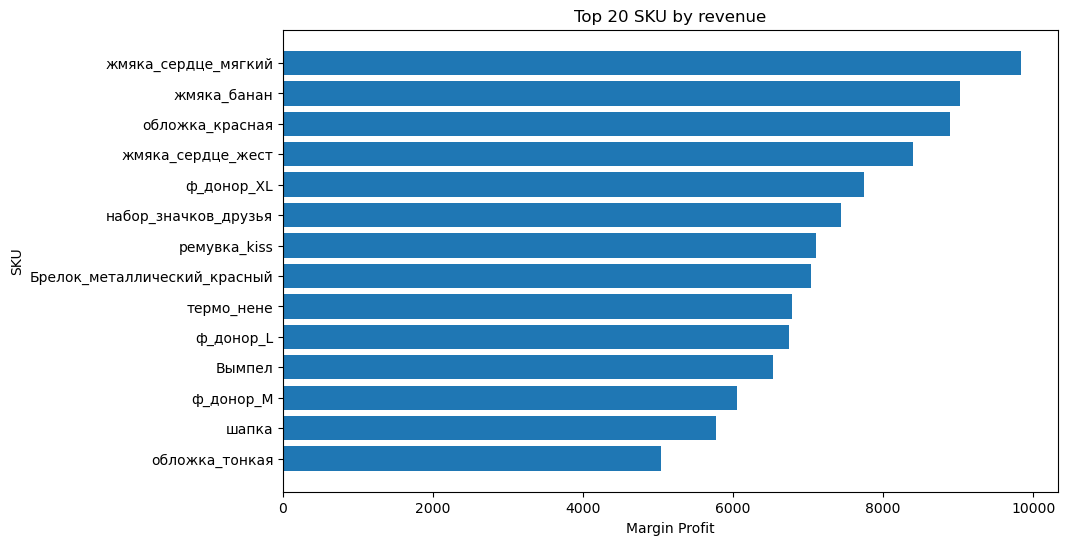

In [60]:
top20_revenue = (
    sales_fact
    .sort_values("revenue", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top20_revenue["sku"],
    top20_revenue["revenue"]
)

plt.xlabel("Margin Profit")
plt.ylabel("SKU")
plt.title("Top 20 SKU by revenue")

plt.gca().invert_yaxis()

plt.show()

In [61]:
# 4.5 SKU by losing position
loss_making = (
    sales_fact[
        sales_fact["gross_profit"] < 0].sort_values("gross_profit"))

loss_making[[
        "sku",
        "product_name",
        "revenue",
        "gross_profit",
        "profit_margin_pct"]]

,sku,product_name,revenue,gross_profit,profit_margin_pct
284,ф_донор_L,"Футболка ""Донор крови, донор жизни!"", Размер L...",3471.00,-10952.54,-315.54
458,шоппер_красный,Сумка шоппер от Сообщества доноров DonorSearch...,1220.68,-8560.01,-701.25
279,ф_донор_M,"Футболка ""Донор крови, донор жизни!"", Размер M...",4675.00,-7011.29,-149.97
450,термо_ДС,Термостакан термокружка сообщества доноров Don...,1171.00,-5692.06,-486.09
312,попсокет,Попсокет донора сообщества DonorSearch,902.00,-2430.41,-269.45
...,...,...,...,...,...
187,шоппер_красный,Сумка шоппер от Сообщества доноров DonorSearch...,764.00,-7.58,-0.99
234,сб_(4-)_белый,Силиконовый браслет донора сообщества DonorSea...,0.00,-7.20,NaN
40,сб_(4-)_белый,Силиконовый браслет донора сообщества DonorSea...,0.00,-4.20,NaN
233,сб_(3-)_белый,Силиконовый браслет донора сообщества DonorSea...,0.00,-3.30,NaN


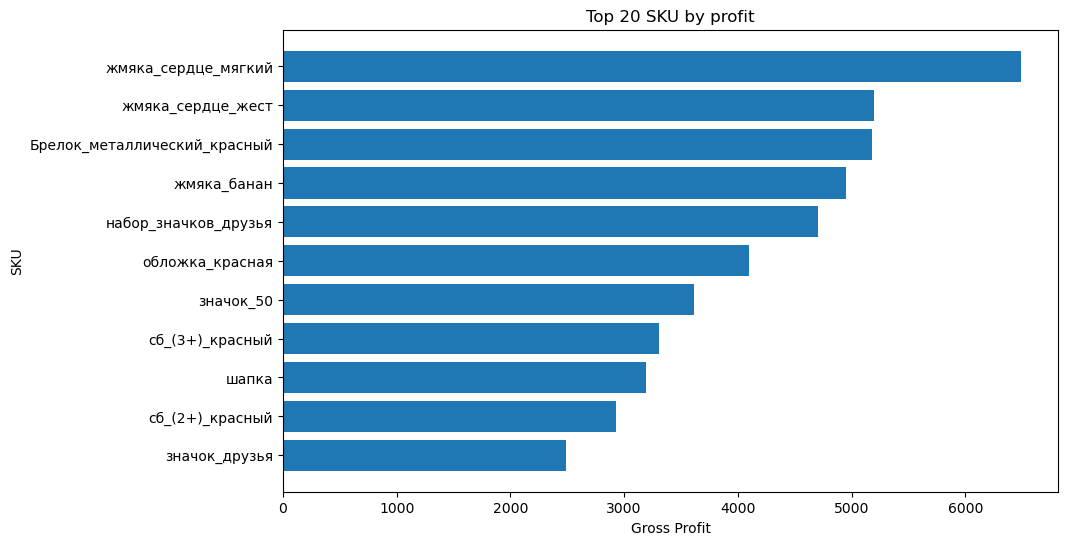

In [62]:
# 4.6 SKY by Profit
top20_profit = (
    sales_fact
    .sort_values("gross_profit", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top20_profit["sku"],
    top20_profit["gross_profit"]
)

plt.xlabel("Gross Profit")
plt.ylabel("SKU")
plt.title("Top 20 SKU by profit")

plt.gca().invert_yaxis()

plt.show()

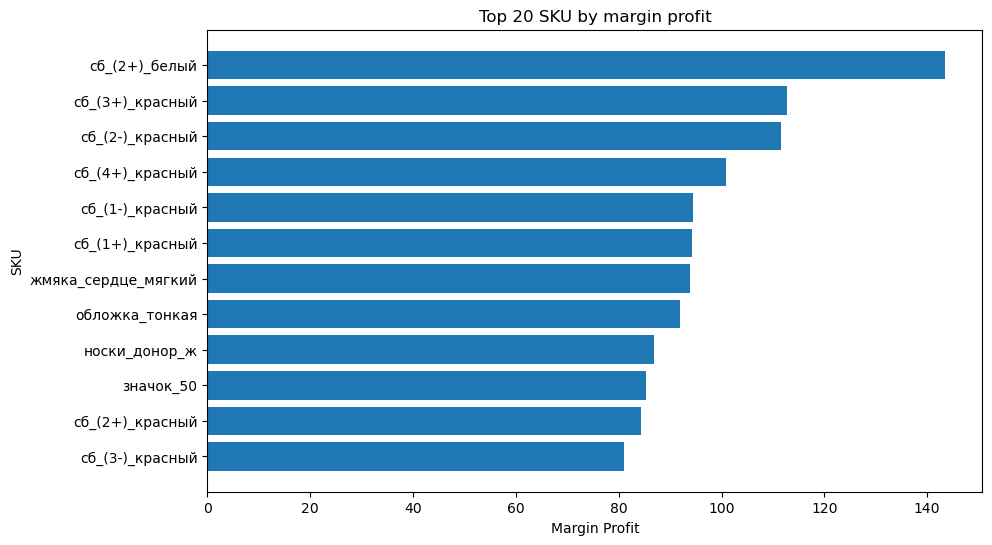

In [63]:
top20_margin_profit = (
    sales_fact
    .sort_values("profit_margin_pct", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top20_margin_profit["sku"],
    top20_margin_profit["profit_margin_pct"]
)

plt.xlabel("Margin Profit")
plt.ylabel("SKU")
plt.title("Top 20 SKU by margin profit")

plt.gca().invert_yaxis()

plt.show()

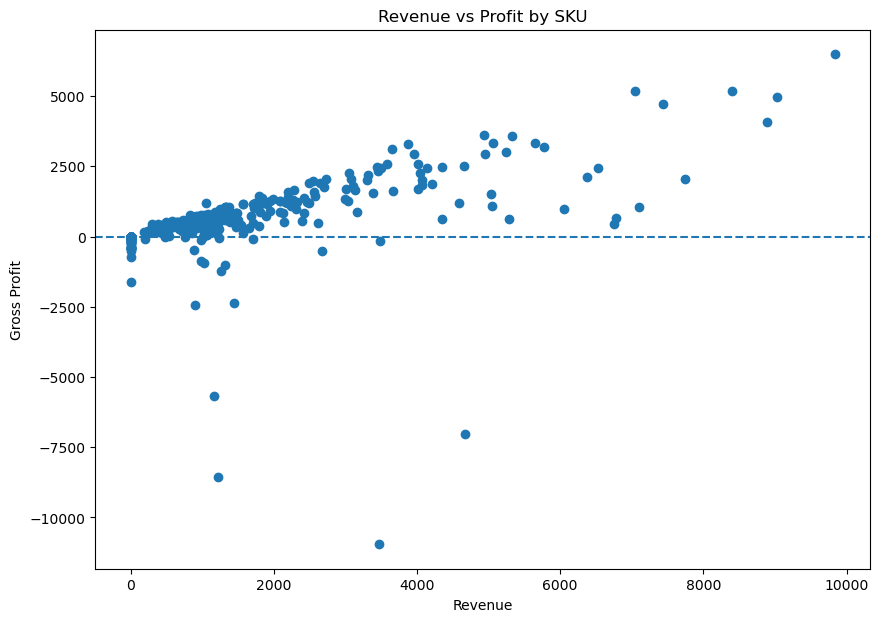

In [64]:
plt.figure(figsize=(10, 7))

plt.scatter(
    sales_fact["revenue"],
    sales_fact["gross_profit"]
)

plt.xlabel("Revenue")
plt.ylabel("Gross Profit")
plt.title("Revenue vs Profit by SKU")

plt.axhline(0, linestyle="--")

plt.show()

* dreapta + sus

→ SKU-uri cu revenue și profit mari
→ profit drivers

dreapta + aproape de 0

→ revenue mare, dar profit mic
→ high revenue / low margin

stânga + sus

→ revenue mai mic, dar economie bună
→ high margin / low volume

sub 0

→ loss-making SKU

## 6. SKU Segmentation: Sales × Margin Matrix

Products are segmented into four groups based on the median sales and median profit margin.

 |Sales \\ Margin |  High Margin |	Low Margin
 |----|----|----|
 |**High Sales**	|Stars	|Volume Drivers
 |**Low Sales** 	|Hidden Gems	|Candidates for Discontinuation


**Segmentation Notes**:
* Stars – Products with high sales and high profit margins. These are the best-performing SKUs.
* Volume Drivers – Products with high sales but low profit margins. They generate sales volume but contribute less to profitability.
* Hidden Gems – Products with low sales but high profit margins. These products have growth potential and may benefit from increased promotion.
* Candidates for Discontinuation (Low-Priority Products) – Products with low sales and low profit margins. These SKUs may be considered for removal from the product portfolio.

* high volume + high margin → Stars
* high volume + low margin → Volume Drivers
* low volume + high margin → Hidden Gems
* low volume + low margin → Candidates / Low Priority

In [65]:
sku_summary = by_sku[by_sku["revenue"] > 0].copy()
sku_summary["margin_pct"] = sku_summary["gross_profit"] / sku_summary["revenue"] * 100

sales_median = sku_summary["qty_delivered"].median()
margin_median = sku_summary["margin_pct"].median()


def get_segment(row):
    high_sales = row["qty_delivered"] >= sales_median
    high_margin = row["margin_pct"] >= margin_median
    if high_sales and high_margin:
        return "Stars"
    if high_sales and not high_margin:
        return "Volume Drivers"
    if not high_sales and high_margin:
        return "Hidden Gems"
    return "Candidates for Discontinuation"


sku_summary["segment"] = sku_summary.apply(get_segment, axis=1)

print(f"Sales median: {sales_median:.1f} units., margin median: {margin_median:.1f}%")
print(sku_summary["segment"].value_counts())
sku_summary.sort_values("gross_profit", ascending=False).head(10)


Sales median: 15.0 units., margin median: 50.1%
segment
Stars                             16
Volume Drivers                    16
Hidden Gems                       15
Candidates for Discontinuation    15
Name: count, dtype: int64


,sku,product_name,revenue,qty_delivered,gross_profit,margin_pct,segment
9,жмяка_сердце_мягкий,"Кистевой эспандер DonorSearch ""Жмяка"" сердце м...",38480.04,56,23918.42,62.157992,Stars
8,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" жесткая",35918.15,54,22775.18,63.408555,Stars
10,значок_50,"Значок DonorSearch ""50 донаций"", металл, 26x19...",26247.33,22,19458.36,74.134626,Stars
23,обложка_красная,Обложка для паспорта DonorSearch экокожа красн...,25018.93,44,12523.59,50.056457,Volume Drivers
2,Брелок_металлический_красный,Брелок для ключей автомобиля DonorSearch метал...,18451.79,29,12448.46,67.464783,Stars
7,жмяка_банан,"Кистевой эспандер DonorSearch ""Жмяка"" банан",24196.08,32,12117.97,50.082369,Stars
18,набор_значков_друзья,Набор металлических значков DonorSearch для др...,20185.41,8,12109.41,59.990904,Hidden Gems
11,значок_друзья,Металлический значок DonorSearch для друзей со...,20425.56,19,11791.67,57.729972,Stars
31,сб_(1+)_красный,Силиконовый браслет 0(I) Rh+ (1+) донора сообщ...,14132.37,49,10850.52,76.777780,Stars
35,сб_(2+)_красный,Силиконовый браслет A(II) Rh+ (2+) донора сооб...,11536.51,39,8485.68,73.555001,Stars


**STARS**:  Best product. Keep high stock levels.

 **Volume Drivers** : High sales but low margin. Increase price slightly.
 
**Hidden Gems** :"BOOST ADS: High margin but low sales. Increase marketing budget.

**Candidates for Discontinuation** : "DISCONTINUE: Low sales and low profit. Remove from catalog.


In [66]:
print(f"Number of product_name:",by_sku["product_name"].nunique())
print(f"Number of sku:",by_sku["sku"].nunique())

Number of product_name: 59
Number of sku: 64


In [67]:
monthly_qty = sales_fact.pivot_table(
    index="sku",
    columns="year_month",
    values="delivered_qty",
    aggfunc="sum",
    fill_value=0
)

In [68]:
monthly_qty

year_month,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
sku,,,,,,,,,,,,,
Бафф_красный,0,0,0,0,0,0,3,0,0,0,0,0,0
Брелок_металлический_голубой,0,0,0,0,0,0,0,0,2,1,0,1,0
Брелок_металлический_красный,0,0,0,0,0,0,10,8,0,7,0,4,0
Брелок_металлический_розовый,0,0,0,0,0,0,0,1,2,1,0,1,0
Вымпел,0,0,0,0,0,0,0,0,0,5,8,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ф_донор_M,1,4,5,14,0,0,0,0,0,0,0,0,0
ф_донор_S,0,0,0,0,0,0,0,0,0,0,0,0,0
ф_донор_XL,4,1,7,4,0,0,2,0,0,0,0,0,0


In [69]:
# Coefficient of Variation(CV) = Standard deviation / Mean
# monthly sales → Standard deviation → monthly mean → std / mean → sales_cv
cv = (monthly_qty.std(axis=1) / monthly_qty.mean(axis=1).replace(0, np.nan)).rename("sales_cv")
sku_summary = sku_summary.merge(cv.reset_index(), on="sku", how="left")

print("SKU with unstable demand (large fluctuations in monthly sales):")
sku_summary.sort_values("sales_cv", ascending=False)[["sku", "qty_delivered", "sales_cv"]].head(10)


SKU with unstable demand (large fluctuations in monthly sales):


,sku,qty_delivered,sales_cv
57,стикерпак_желтый,44,3.605551
43,Бафф_красный,3,3.605551
48,термо_450,1,3.605551
53,сб_(3-)_белый,1,3.605551
47,термо_сдавал,3,3.605551
51,ф_бег_S,1,3.605551
55,стикерпак_голубой,39,3.226051
59,термо_ДС,9,3.196577
52,термо_нене,8,3.149487
60,шоппер_красный,19,3.003461


**Low CV → stable demand
**High CV → unstable/fluctuating demand

In [95]:
sales_median = sku_summary["qty_delivered"].median()
margin_median = sku_summary["margin_pct"].median()
revenue_median = sku_summary["revenue"].median()

print("Revenue median:", revenue_median)
print("Margin median:", margin_median)

# Hight Revenue + Hight Margin
high_revenue_high_margin = sku_summary[
    (sku_summary["revenue"] >= revenue_median) &
    (sku_summary["margin_pct"] >= margin_median)
].copy()

high_revenue_high_margin = high_revenue_high_margin.sort_values(
    "gross_profit",
    ascending=False
)
display(f"SKU with high Revenue and High Margin",high_revenue_high_margin[
    ["sku", "revenue","qty_delivered", "gross_profit", "margin_pct", "segment"]
])

Revenue median: 4680.365
Margin median: 50.069412982420474


'SKU with high Revenue and High Margin'

,sku,revenue,qty_delivered,gross_profit,margin_pct,segment
0,жмяка_сердце_мягкий,38480.04,56,23918.42,62.157992,Stars
1,жмяка_сердце_жест,35918.15,54,22775.18,63.408555,Stars
2,значок_50,26247.33,22,19458.36,74.134626,Stars
4,Брелок_металлический_красный,18451.79,29,12448.46,67.464783,Stars
5,жмяка_банан,24196.08,32,12117.97,50.082369,Stars
6,набор_значков_друзья,20185.41,8,12109.41,59.990904,Hidden Gems
7,значок_друзья,20425.56,19,11791.67,57.729972,Stars
8,сб_(1+)_красный,14132.37,49,10850.52,76.777780,Stars
9,сб_(2+)_красный,11536.51,39,8485.68,73.555001,Stars
10,сб_(3+)_красный,8977.95,31,7309.08,81.411458,Stars


In [94]:
print("Revenue median:", revenue_median)
print("Margin median:", margin_median)

# Identifing SKU's with ----> High Revenue + Low Margin”
high_revenue_low_margin = sku_summary[
    (sku_summary["revenue"] >= revenue_median) &
    (sku_summary["margin_pct"] < margin_median)
].copy()

high_revenue_low_margin = high_revenue_low_margin.sort_values(
    "revenue",
    ascending=False
)
print("")
display(f"SKU with high Revenue and Low Margin",high_revenue_low_margin[
    ["sku", "revenue", "gross_profit", "margin_pct","qty_delivered", "segment"]
])

Revenue median: 4680.365
Margin median: 50.069412982420474



'SKU with high Revenue and Low Margin'

,sku,revenue,gross_profit,margin_pct,qty_delivered,segment
3,обложка_красная,25018.93,12523.59,50.056457,44,Volume Drivers
16,ф_донор_XL,19989.18,4214.93,21.086058,18,Volume Drivers
61,ф_донор_L,17874.36,-11418.24,-63.880553,29,Volume Drivers
58,ф_донор_M,17340.16,-6427.54,-37.067363,24,Volume Drivers
13,Вымпел,17112.77,6386.71,37.321310,22,Volume Drivers
27,бутылка_650,15707.23,2520.78,16.048533,19,Volume Drivers
12,ремувка,13822.83,6728.83,48.679106,30,Volume Drivers
23,ремувка_kiss,12530.60,2916.29,23.273347,44,Volume Drivers
19,обложка_тонкая,10812.57,3989.09,36.893079,33,Volume Drivers
17,носки_донор_м,9171.53,4175.21,45.523593,20,Volume Drivers


In [85]:
# Sort the table by margin, from lowest to highest
worst_product = sku_summary.sort_values(by="margin_pct", ascending=True).iloc[0]

worst_sku = worst_product["sku"]
worst_margin = round(worst_product["margin_pct"], 2)
worst_profit = round(worst_product["gross_profit"], 2)

print(f"The lowest profitability is for SKU {worst_sku} with a margin of {worst_margin}% (Total profit: {worst_profit} RUB.).")


The lowest profitability is for SKU термо_ДС with a margin of -296.43% (Total profit: -6583.69 RUB.).


In [98]:
print(f"sku with high margin but low sales:")
h_gems = sku_summary[sku_summary["segment"] == "Hidden Gems"]
h_gems[["sku","revenue","qty_delivered","gross_profit","margin_pct"]]

sku with high margin but low sales:


,sku,revenue,qty_delivered,gross_profit,margin_pct
6,набор_значков_друзья,20185.41,8,12109.41,59.990904
20,шапка,7201.91,5,3980.45,55.269366
26,магнит,4063.10,13,2541.11,62.541163
28,сб_(2+)_белый,3033.87,10,2371.67,78.173092
31,ф_бег_XL,3957.90,3,2038.89,51.514439
32,Брелок_металлический_розовый,3119.33,5,1993.47,63.906993
33,сб_(3+)_белый,2782.91,8,1980.12,71.152858
34,сб_(1+)_белый,2505.47,8,1783.83,71.197420
37,сб_(4-)_красный,2906.45,10,1490.96,51.298319
38,Брелок_металлический_голубой,2497.49,4,1429.55,57.239468


In [88]:
print(f"10 SKU with lowest profitability")
sku_summary[
    ["sku","margin_pct","gross_profit","revenue"]
].sort_values("margin_pct").head(10)


10 SKU with lowest profitability


,sku,margin_pct,gross_profit,revenue
59,термо_ДС,-296.429086,-6583.69,2221.00
60,шоппер_красный,-260.041320,-10421.91,4007.79
57,стикерпак_желтый,-242.101038,-3498.36,1445.00
56,попсокет,-112.886520,-2402.18,2127.96
61,ф_донор_L,-63.880553,-11418.24,17874.36
58,ф_донор_M,-37.067363,-6427.54,17340.16
55,стикерпак_голубой,-25.252012,-944.40,3739.90
54,стикерпак_белый,-0.620331,-16.40,2643.75
52,термо_нене,3.285185,256.16,7797.43
50,картхолдер_магнит_ч,12.669345,318.52,2514.10


In [70]:
sales_fact = sales_fact.sort_values(['sku', 'year_month'])

sales_fact['price_pct_change'] = sales_fact.groupby('sku')['avg_price_per_unit'].pct_change().round(2)
sales_fact['qty_pct_change'] = sales_fact.groupby('sku')['delivered_qty'].pct_change().round(2)

# Calculate Price Elasticity of Demand (PED)
# Elasticity < -1 means price cuts heavily boost volume. Elasticity > -1 means volume is rigid.
sales_fact['elasticity'] = sales_fact['qty_pct_change'] / sales_fact['price_pct_change'].replace(0, np.nan)

# Isolate items where price hikes DID NOT drop volume (Prime Repricing Candidates)
repricing_candidates = sales_fact[
    (sales_fact['price_pct_change'] > 0.05) & 
    (sales_fact['qty_pct_change'] >= 0)
]
print("Repricing Candidates (Price increased, but sales stayed stable or grew):")
repricing_candidates[['sku', 'year_month', 'price_pct_change', 'qty_pct_change']].head(30)

Repricing Candidates (Price increased, but sales stayed stable or grew):


,sku,year_month,price_pct_change,qty_pct_change
392,Брелок_металлический_голубой,2026-03,inf,inf
71,Брелок_металлический_голубой,2026-06,inf,inf
51,Брелок_металлический_красный,2026-06,inf,inf
260,Брелок_металлический_розовый,2026-02,inf,inf
69,Брелок_металлический_розовый,2026-06,inf,inf
101,авто_красный,2026-04,inf,inf
345,бутылка_650,2025-08,0.14,2.00
253,жмяка_банан,2026-02,inf,inf
427,жмяка_сердце_жест,2025-09,0.08,0.17
389,жмяка_сердце_жест,2026-03,0.29,1.00


In [71]:
# 3.2 Portfolio Strategy Mapping
def assign_strategic_action(row):
    segment = row['segment']
    cv = row['sales_cv']
    profit = row['gross_profit']
    
    if segment == "Stars" and cv <= 1.2:
        return "SCALE: Increase stock in main clusters and keep good product availability."

    elif segment == "Stars" and cv > 1.2:
        return "SCALE CAREFULLY: High profit but unstable demand. Order smaller batches more often."

    elif segment == "Hidden Gems":
        return "BOOST ADS: High profit margin but low sales volume. Increase advertising to improve visibility."

    elif segment == "Volume Drivers":
        return "REDUCE COSTS / REPRICE: High sales but low profit margin. Reduce costs or test a higher price."

    elif segment == "Candidates for Discontinuation" or profit < 0:
        return "DISCONTINUE & LIQUIDATE: Reduce marketing and use discounts to sell remaining stock."

    return "TESTING: Continue monitoring sales and performance."

sku_summary['strategic_action'] = sku_summary.apply(assign_strategic_action, axis=1)

print("📋 ACTION-ITEM ASSIGNMENT FOR MANAGEMENT:")
sku_summary[['sku', 'segment', 'sales_cv', 'strategic_action']].head(10)

print(sku_summary['strategic_action'].value_counts())


📋 ACTION-ITEM ASSIGNMENT FOR MANAGEMENT:
strategic_action
REDUCE COSTS / REPRICE: High sales but low profit margin. Reduce costs or test a higher price.     16
BOOST ADS: High profit margin but low sales volume. Increase advertising to improve visibility.    15
DISCONTINUE & LIQUIDATE: Reduce marketing and use discounts to sell remaining stock.               15
SCALE: Increase stock in main clusters and keep good product availability.                         11
SCALE CAREFULLY: High profit but unstable demand. Order smaller batches more often.                 5
Name: count, dtype: int64


In [72]:
pricing_plot = price_analysis[
    price_analysis["price_change_pct"].notna()
    & price_analysis["qty_change_pct"].notna()
].copy()

pricing_plot = pricing_plot[
    np.isfinite(pricing_plot["price_change_pct"])
    & np.isfinite(pricing_plot["qty_change_pct"])
]

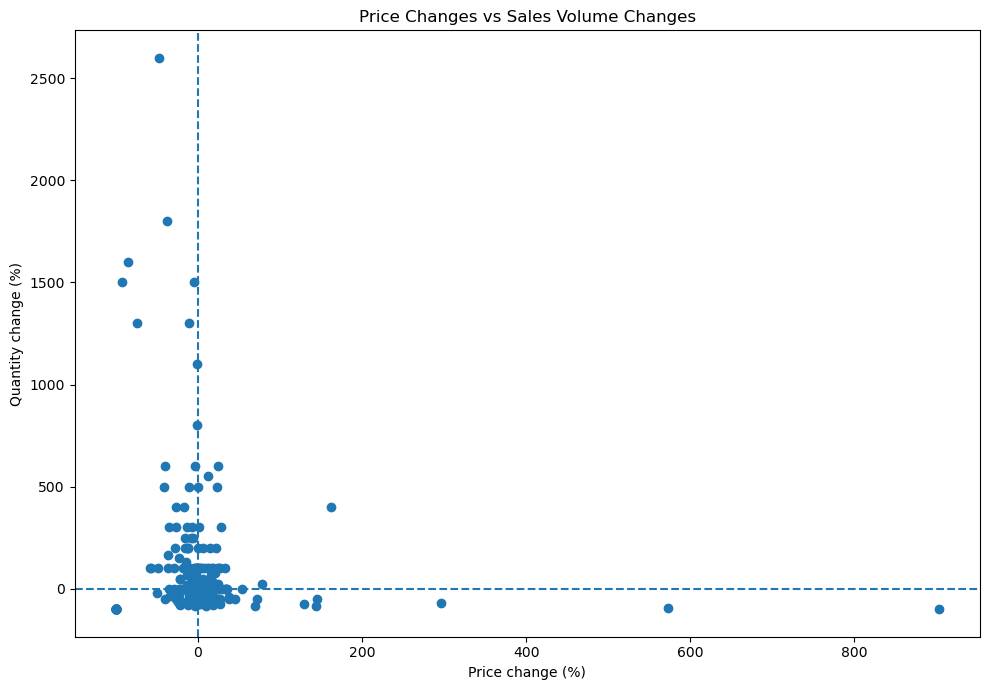

In [73]:
plt.figure(figsize=(10, 7))

plt.scatter(
    pricing_plot["price_change_pct"],
    pricing_plot["qty_change_pct"]
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Price change (%)")
plt.ylabel("Quantity change (%)")
plt.title("Price Changes vs Sales Volume Changes")

plt.tight_layout()
plt.show()

## 7. Cost Leakage Analytics

In [89]:
# Re-extract itemized costs to find the biggest profit eaters across the whole store
leak_summary = unit_economics[[
    "Логистика", "Стоимость размещения", "Обратная логистика", 
    "Обработка возврата", "Оплата за клик", "Оплата за заказ"
]].sum().rename("Total_Cost_RUB").reset_index()

leak_summary['Share_of_Total_Costs_%'] = (leak_summary['Total_Cost_RUB'] / leak_summary['Total_Cost_RUB'].sum() * 100).round(2)
print("📌 WHERE MONEY IS LEAKING (Ranked highest to lowest):")
leak_summary.sort_values("Total_Cost_RUB", ascending=False)

📌 WHERE MONEY IS LEAKING (Ranked highest to lowest):


,index,Total_Cost_RUB,Share_of_Total_Costs_%
4,Оплата за клик,0.00,-0.00
5,Оплата за заказ,0.00,-0.00
3,Обработка возврата,-510.00,0.55
2,Обратная логистика,-2990.53,3.25
1,Стоимость размещения,-33547.12,36.45
0,Логистика,-54979.66,59.74


In [101]:
# Calculate current store total gross profit
current_total_profit = sales_fact['gross_profit'].sum()

# Identify top 5 loss-making SKUs
top_bleeders = loss_making.groupby('sku')['gross_profit'].sum().sort_values().head(5).index

# Simulate removing them (adding their losses back to the budget)
bleeding_losses = abs(loss_making[loss_making['sku'].isin(top_bleeders)]['gross_profit'].sum())
simulated_profit = current_total_profit + bleeding_losses

print(f"🚀 90-DAY STRATEGIC IMPACT RECOMMENDATION:")
print(f"Current Store Profit: {current_total_profit:,.2f} RUB")
print(f"Action: Discontinue or pause the top 5 bleeding SKUs: {list(top_bleeders)}")
print(f"Recovered Capital: +{bleeding_losses:,.2f} RUB")
print(f"New Projected Store Profit: {simulated_profit:,.2f} RUB (An immediate profit increase of {(bleeding_losses/current_total_profit*100):.2f}%)")



🚀 90-DAY STRATEGIC IMPACT RECOMMENDATION:
Current Store Profit: 217,276.30 RUB
Action: Discontinue or pause the top 5 bleeding SKUs: ['ф_донор_L', 'шоппер_красный', 'ф_донор_M', 'термо_ДС', 'стикерпак_желтый']
Recovered Capital: +42,557.26 RUB
New Projected Store Profit: 259,833.56 RUB (An immediate profit increase of 19.59%)


In [76]:
# 3.1 Expanded Itemized Monthly Unit Economics Engine
sales_fact['delivered_qty_safe'] = sales_fact['delivered_qty'].replace(0, np.nan)

# Map precise itemized operational costs per individual delivered unit
sales_fact['unit_cogs'] = sales_fact['cogs']
sales_fact['unit_ozon_commission'] = sales_fact['ozon_commission'] / sales_fact['delivered_qty_safe']
sales_fact['unit_logistics'] = sales_fact['logistics'] / sales_fact['delivered_qty_safe']
sales_fact['unit_storage'] = sales_fact['storage'] / sales_fact['delivered_qty_safe']
sales_fact['unit_return_processing'] = sales_fact['return_processing'] / sales_fact['delivered_qty_safe']
sales_fact['unit_reverse_logistics'] = sales_fact['reverse_logistics'] / sales_fact['delivered_qty_safe']

# Isolate direct promotional / marketing costs per unit
sales_fact['unit_ads_click'] = sales_fact['star_products'] / sales_fact['delivered_qty_safe'] # or map raw marketing columns if present

# Contribution Profit = Revenue - COGS - All Direct Variable Marketplace & Marketing Costs
sales_fact['contribution_profit_per_unit'] = (
    sales_fact['avg_price_per_unit'] 
    - sales_fact['unit_cogs'] 
    - sales_fact['unit_ozon_commission'].fillna(0)
    - sales_fact['unit_logistics'].fillna(0)
    - sales_fact['unit_storage'].fillna(0)
    - sales_fact['unit_return_processing'].fillna(0)
    - sales_fact['unit_reverse_logistics'].fillna(0)
    - sales_fact['unit_ads_click'].fillna(0)
)

sales_fact['total_contribution_profit'] = sales_fact['contribution_profit_per_unit'] * sales_fact['delivered_qty']

print("Month-by-Month Granular Unit Economics Sample:")
sales_fact[['year_month', 'sku', 'avg_price_per_unit', 'contribution_profit_per_unit', 'total_contribution_profit']].head(20)


Month-by-Month Granular Unit Economics Sample:


,year_month,sku,avg_price_per_unit,contribution_profit_per_unit,total_contribution_profit
317,2026-01,Бафф_красный,1013.01,546.083333,1638.25
334,2026-01,Брелок_металлический_голубой,0.00,-190.000000,-0.00
270,2026-02,Брелок_металлический_голубой,0.00,-190.000000,-0.00
392,2026-03,Брелок_металлический_голубой,680.42,547.800000,1095.60
112,2026-04,Брелок_металлический_голубой,610.93,477.350000,477.35
238,2026-05,Брелок_металлический_голубой,0.00,-190.000000,-0.00
71,2026-06,Брелок_металлический_голубой,525.71,417.510000,417.51
8,2026-07,Брелок_металлический_голубой,0.00,-190.000000,-0.00
315,2026-01,Брелок_металлический_красный,703.82,572.147000,5721.47
251,2026-02,Брелок_металлический_красный,665.96,533.206250,4265.65


In [77]:
# Calculate %  of profitability for 16 most profitable sku
top_skus_profit_share = (
    sku_summary.nlargest(16, "gross_profit")["gross_profit"].sum()
    / sku_summary["gross_profit"].sum()
    * 100
).round(2)
print(top_skus_profit_share)

85.16


## Выводы и рекомендации

**1. Прибыльность и юнит-экономика**

Анализ показал, что основные финансовые результаты формируются за счет 16 наиболее прибыльных SKU, которые обеспечивают 83,16 % общей прибыли, но одновременно теряет огромную часть прибыли на товарах из-за критически низких цен или высоких скидок.

**1. Категория: Высокая выручка и Высокая маржа («Звезды»)** 
Это главные продукты компании. Они приносят и оборот, и чистые деньги. Их нужно беречь от OOS (дефицита).
** Абсолютные лидеры:** 
- жмяка_сердце_мягкий	
- жмяка_сердце_жест	
- значок_50	
- Брелок_металлический_красный	
- жмяка_банан	
- набор_значков_друзья	
- значок_друзья	
- сб_(1+)_красный	
- сб_(2+)_красный	
- сб_(3+)_красный	
- авто_красный	
- носки_донор_ж	
- сб_(1-)_красный
- сб_(3-)_красный	
- шапка	
- сб_(4+)_красный
**Лидеры по доходу:**
- Игрушки-антистресс (`жмяка_сердце_мягкий/жест`) и `значок_50`. 
- Они приносят самую большую выручку при отличной маржинальности 62–74%.
**Стабильная маржа:** `Металлические брелки` и `наборы значков` уверенно держат маржу около 60–67%.
**Сверхприбыльные ниши:** `сб_красный` показывают рекордную маржинальность до 81.4%.
**Рекомендация:** Обеспечить их постоянное наличие на складе (избегать OOS). Запретить любые глубокие скидки на эти позиции.

**2. Категория: Высокая выручка и Низкая маржа** - Эти товары делают оборот, но либо приносят копейки, либо прямо снижает прибыль.
- `ф_донор_L`: Выручка 17.8 тыс., но чистый убыток составляет -11 418.24 (маржа -63.88%).
- `ф_донор_M`: Выручка 17.3 тыс., убыток составляет -6 427.54 (маржа -37.07%).Причина: Эти футболки продаются намного ниже себестоимости, либо по ним применили ошибочные скидки. Каждый проданный товар приносит компании прямой минус.
- `термо_нене`- низкая эффективность, работает «вхолостую» — при выручке почти 7.8 тыс., прибыль составляет всего 256.16 (маржа 3.28%).
- `бутылка_650` также имеет слабую маржу (16%).
**Рекомендация:**
- Поднять цены или отменить скидки на `футболки ф_донор_L и M`. Продавать их с текущим минусом категорически нельзя.
- Позиции `термо_нене` и `бутылка_650` перевести на модель работы под заказ или поднять цену на 15–20%. Если спрос упадет — компания ничего не потеряет.

**3. Категория: Высокая маржа, низкие продажи** 
 Эти товары обладают отличной доходностью (маржинальность от 51% до 78%), но продаются в штучном количестве (от 1 до 13 единиц). Они не приносят много денег из-за низкого спроса или дефицита на складе. Цель бизнеса — раскачать объемы продаж, строго удерживая текущие высокие цены.
- Лидеры группы — `набор_значков_друзья` (маржа 60%) и `шапка` (маржа 55%) приносят отличную прибыль с каждой штуки.
* Список SKU с Высокой маржой, низкие продажи:
###### _________________________________________________
- набор_значков_друзья
- шапка	
- магнит	
- сб_(2+)_белый	
- ф_бег_XL	
- Брелок_металлический_розовый	
- сб_(3+)_белый	
- сб_(1+)_белый	
- сб_(4-)_красный	
- Брелок_металлический_голубой	
- носки_кровь_м	
- сб_(1-)_белый	
- сб_(4+)_белый	
- сб_(2-)_белый	
- сб_(3-)_белый	



**План на 90 дней** 
- Текущая прибыль магазина составляет 217 276.30 RUB, но бизнес несёт критические потери в двух направлениях: содержание убыточных товаров и огромные затраты на хранение неликвида.
- Пять товаров — `ф_донор_L`, `шоппер_красный`, `ф_донор_M`, `термо_ДС` и `стикерпак_желтый` — работают в чистый минус и сжигают деньги компании.Остановить закупки или вывести эти 5 позиций из продаж.
Анализ расходов показывает, что ключевой фокус оптимизации должен быть направлен на `Логистику` и `Стоимость размещения (Хранение)`, которые суммарно съедают 96.19% всех операционных затрат
- Прямая логистика (59.74% расходов): Самая большая статья затрат (-54 979.66). Это подтверждает выводы из прошлого анализа: продавать тяжелые или дешевые товары с низкой маржой (как шопперы или убыточные футболки) категорически нельзя, так как логистика полностью съедает их цену.
- Стоимость размещения / Хранение (36.45% расходов): Компания платит колоссальные -33 547.12 за то, что товар просто лежит на складе. Это прямой признак затоваренности (overstock) неходовыми позициями. Деньги «заморожены» на полках склада.
- Обратная логистика и возвраты (3.8% расходов): Затраты минимальны (~3 500), что говорит о хорошем качестве товара,покупатели редко отказываются от посылок.
- Причина убытков — не возвраты, а неэффективное управление складом.
- Врзможно необходимо не просто перестать продавать топ-5 убыточных товаров, а физически распродать их остатки в ноль (даже через ликвидационные скидки). Это снизит расходы на хранение, которые сейчас составляют более трети всех затрат магазина.
